## Access Satellite GHRSST L3S 1Day day time Multi Sensor Australia (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_ghrsst_l3s_1day_daytime_multi_sensor_australia data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/52ad55a5-b537-4e10-8a81-22d9317c81f2).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_ghrsst_l3s_1day_daytime_multi_sensor_australia.ipynb).


In [1]:
dataset_name = "satellite_ghrsst_l3s_1day_daytime_multi_sensor_australia"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.11 environment at: /home/lbesnard/miniforge3/envs/AodnCloudOptimised
Resolved 241 packages in 62ms
Audited 241 packages in 1ms


✅ Local version 0.3.8 is up to date (remote: 0.3.3)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3549: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 557 ms, sys: 50.7 ms, total: 608 ms
Wall time: 1.69 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	time = 5046 ;
	lat = 4500 ;
	lon = 6000 ;

variables:
	float32 dt_analysis(time, lat, lon) ;
		dt_analysis:units = kelvin ;
	object filename(time) ;
	float32 l2p_flags(time, lat, lon) ;
	float32 lat(lat) ;
		lat:units = degrees_north ;
	float32 lon(lon) ;
		lon:units = degrees_east ;
	float32 quality_level(time, lat, lon) ;
	float32 satellite_zenith_angle(time, lat, lon) ;
		satellite_zenith_angle:units = angular_degree ;
	float32 sea_surface_temperature(time, lat, lon) ;
		sea_surface_temperature:units = kelvin ;
	float32 sses_bias(time, lat, lon) ;
		sses_bias:units = kelvin ;
	float32 sses_count(time, lat, lon) ;
		sses_count:units = count ;
	float32 sses_standard_deviation(time, lat, lon) ;
		sses_standard_deviation:units = kelvin ;
	float32 sst_count(time, lat, lon) ;
		sst_count:units = count ;
	float64 sst_dtime(time, lat, lon) ;
		sst_dtime:units = second ;
	float32 sst_mean(time, lat, lon) ;
		sst_mean:units = kelvin ;
	float32 sst_standard_deviat

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2012-01-01 03:20:00'), Timestamp('2025-11-29 03:20:00'))

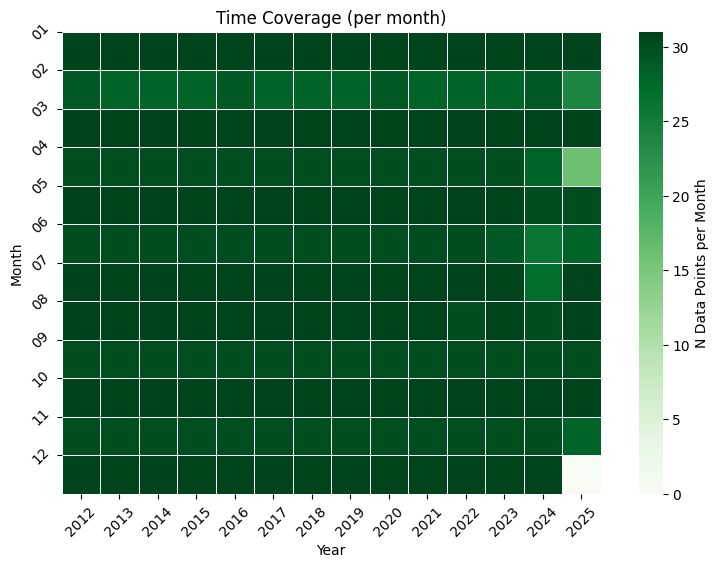

In [7]:
aodn_dataset.plot_time_coverage()

## Timeseries at a point

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:1639: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = df[self.var_name].resample(resample)


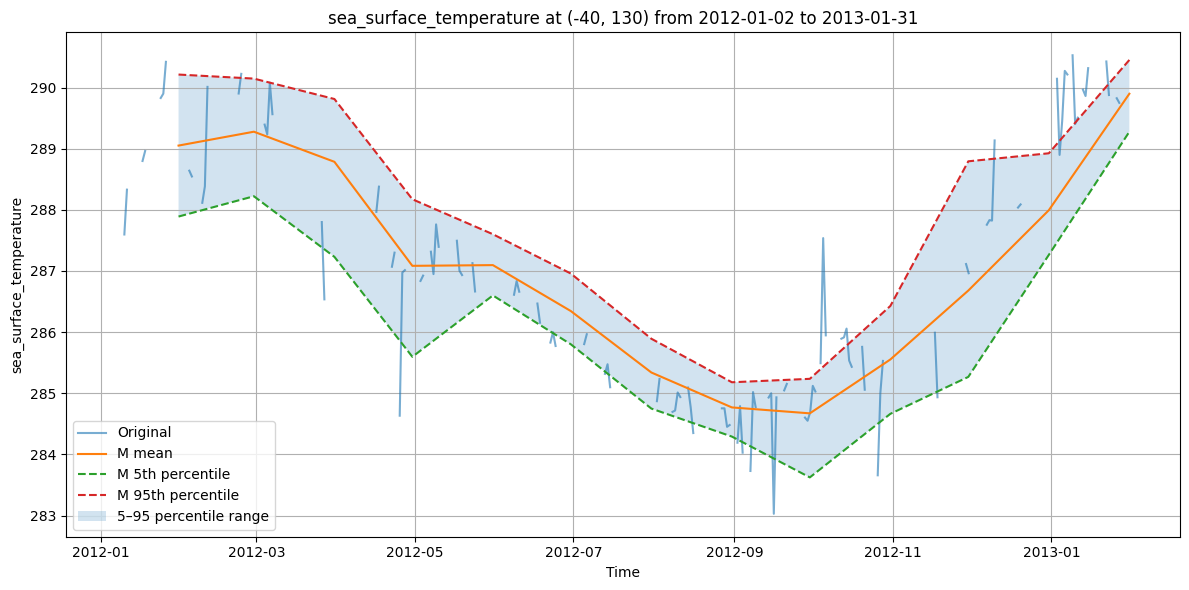

CPU times: user 2.7 s, sys: 405 ms, total: 3.11 s
Wall time: 9.63 s


In [8]:
%%time
time_series_df = aodn_dataset.get_timeseries_data(var_name='sea_surface_temperature', 
                                                  lat=-40, 
                                                  lon=130, 
                                                  date_start='2012-01-02', 
                                                  date_end='2013-01-31', 
                                                  lon_name_override="lon", 
                                                  lat_name_override="lat").plot_timeseries()

## Plot a gridded variable

2026-03-19 10:55:42,380 - aodn.GetAodn - INFO - Plotting 'sea_surface_temperature' for 30 time steps.


/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:2995: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


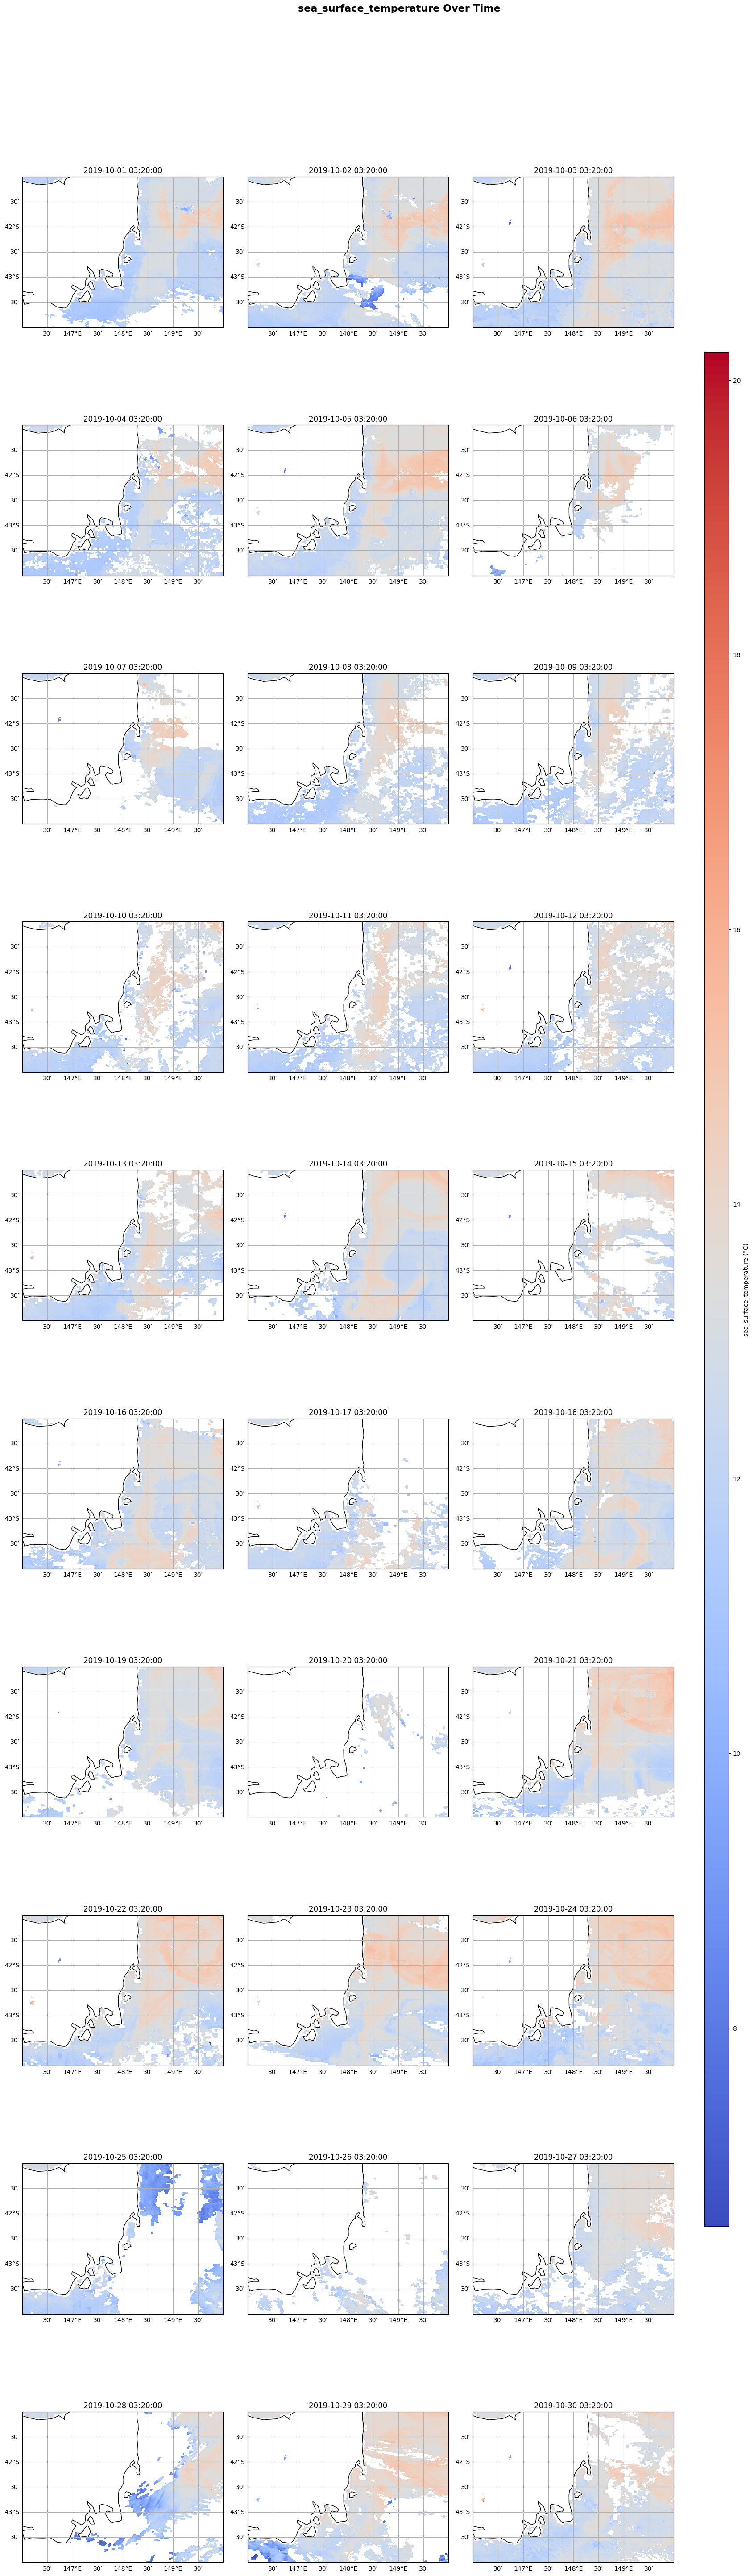

CPU times: user 14.1 s, sys: 10.2 s, total: 24.3 s
Wall time: 39.7 s


In [9]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='sea_surface_temperature', 
                                                    date_start='2019-10-01',                                                
                                                    lon_name_override="lon", 
                                                    lat_name_override="lat", 
                                                    lon_slice=(146, 150), 
                                                    lat_slice=(-44, -41), 
                                                    n_days=30, 
                                                    coastline_resolution="50m", 
                                                    log_scale=False)

In [10]:
aodn_dataset.plot_gridded_variable_viewer_calendar(
    var_name="sea_surface_temperature",
    lon_slice=(145,149),
    lat_slice=(-44,-41),
    coastline_resolution="50m", 
    n_days=31,
)


In [11]:
#aodn_dataset.export_monthly_gridded_pngs(
#    var_name="sea_surface_temperature",
#    lon_slice=(145, 150),
#    lat_slice=(-45, -40),
#)